In [52]:
# Notebook for work analyzing the validity of different structural predictions using different software tools. Also work on determining
# how helpful custom MSAs could be (particularly for multimers). 

In [53]:
from utils import * 
from files.pdb import PDBFile
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass, asdict
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
MIN_LENGTH = 30

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()

# https://pmc.ncbi.nlm.nih.gov/articles/PMC9710616/
print(f'Discarding {(genes_df.seq.apply(len) < MIN_LENGTH).sum()} proteins with length < {MIN_LENGTH} aa.') # Because structures can become untrustworthy.
genes_df = genes_df[genes_df.seq.apply(len) >= MIN_LENGTH].copy()


Discarding 408 proteins with length < 30 aa.


In [55]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

conserved_cluster_ids = dict()
conserved_cluster_ids[1] = level_1_conserved_cluster_ids
conserved_cluster_ids[2] = level_2_conserved_cluster_ids
conserved_cluster_ids[3] = level_3_conserved_cluster_ids

conserved_cluster_gene_ids = dict()
conserved_cluster_gene_ids[1] = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].index.values
conserved_cluster_gene_ids[2] = genes_df[genes_df.cluster_id.isin(level_2_conserved_cluster_ids)].index.values
conserved_cluster_gene_ids[3] = genes_df[genes_df.cluster_id.isin(level_3_conserved_cluster_ids)].index.values

for level, gene_ids in conserved_cluster_gene_ids.items():
    FASTAFile.from_df(genes_df.loc[gene_ids]).write(f'../data/genes/level_{level}_conserved_clusters.faa')

In [56]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_SCORES_PATTERN = r'_scores_rank_001_alphafold2_ptm_model'
COLABFOLD_MSA_PATTERN = r'\.a3m'

gene_ids =  pd.read_csv('../data/genes/genes.csv', index_col=0).index.values # All gene IDs before filtering for length, etc.i
data = {gene_id:{'gene_id':gene_id} for gene_id in genes_df.index}


# ColabFold does not use JackHMMer like AlphaFold2, and instead uses MMseqs. As a result, 
# the MSAs might not be as deep. Rather than using ColabFold as a first pass, it might be better to try ESMFold.

def get_msa_data(path:str):
    '''Read and parse a ColabFold MSA file. These MSAs were constructed using MMseqs, and each header line contains information about the alignment quality. 
    
    :param path: The path to the MSA file. 
    :returns: A dictionary containing (1) the full MSA text, (2) the number of sequences in the MSA, (3) the mean bit score, (4) the minimum bit score, 
        and (5) the maximum bit score. 
    '''
    with open(path, 'r') as f:
        msa = f.read()

    # It seems as though ColabFold embeds statistics from the MMseqs search in the FASTA headers. 
    fields = ['id', 'bit_score', 'identity', 'e_value', 'query_start', 'query_end', 'query_length', 'subject_start', 'subject_end', 'subject_length']
    headers = [line for line in msa.split('\n') if line.startswith('>')]

    df = pd.DataFrame([dict(zip(fields, header.split())) for header in headers])
    if len(df.columns) == 1:
        return {'msa':msa, 'msa_num_seqs':0}
    df = df[~df.bit_score.isnull()].copy()

    info = dict()
    info['msa'] = msa
    info['msa_num_seqs'] = len(df)
    info['msa_mean_bit_score'] = df.bit_score.astype(float).mean()
    info['msa_min_bit_score'] = df.bit_score.astype(float).min()
    info['msa_max_bit_score'] = df.bit_score.astype(float).max()
    return info

if not os.path.exists('analysis-1-structs_colabfold_data.json'):
    for path in tqdm(glob.glob(os.path.join(COLABFOLD_DIR, '*', '*')), desc='Loading ColabFold MSA information.'):    
        try:
            if re.search(COLABFOLD_SCORES_PATTERN, path) is not None:
                data_ = load_json(path)
                data[get_gene_id(path)]['ptm'] = data_['ptm']
                data[get_gene_id(path)]['plddt'] = data_['plddt']
            elif re.search(COLABFOLD_MSA_PATTERN, path) is not None:
                data[get_gene_id(path)].update(get_msa_data(path))
        except KeyError: 
            # Some of the genes I have structures for were filtered out during preprocessing (based on positions, I think because they are partial).
            # Missing orfm.bz_1.1_2, orfm.bz_1.1_190, orfm.bz_10.1_181, orfm.bz_10.1_1, orfm.bz_2.1_165, orfm.bz_2.1_1
            print( f'Skipped {get_gene_id(path)}, which is not present in the genes DataFrame.')

    with open('analysis-1-structs_colabfold_data.json', 'w') as f:
        json.dump(data, f)

else:
    data = load_json('analysis-1-structs_colabfold_data.json')

In [71]:
# Specifically want to look at the cluster_3 ATPase genes. 
gene_ids = genes_df[genes_df.cluster_id == 3].index.values 
for gene_id in gene_ids:
    print(f'Number of sequences in {gene_id} ColabFold MSA:', data[gene_id]['msa_num_seqs'])

Number of sequences in orfm.bz_0.1_191 ColabFold MSA: 23
Number of sequences in orfm.bz_1.1_155 ColabFold MSA: 25
Number of sequences in orfm.bz_2.1_22 ColabFold MSA: 18
Number of sequences in orfm.bz_3.1_43 ColabFold MSA: 14
Number of sequences in orfm.bz_4.1_184 ColabFold MSA: 17
Number of sequences in orfm.bz_5.1_151 ColabFold MSA: 16
Number of sequences in orfm.bz_7.1_194 ColabFold MSA: 27
Number of sequences in orfm.bz_8.1_215 ColabFold MSA: 49
Number of sequences in orfm.bz_9.1_34 ColabFold MSA: 49
Number of sequences in orfm.bz_10.1_15 ColabFold MSA: 24
Number of sequences in orfm.bz_11.1_23 ColabFold MSA: 15


In [57]:
figure_df = genes_df.copy()

for gene_id, data_ in data.items():
    if gene_id not in genes_df.index.values:
        continue 
    
    figure_df.loc[gene_id, 'plddt_upper_quantile'] = np.quantile(data_['plddt'], 0.75)
    figure_df.loc[gene_id, 'plddt_lower_quantile'] = np.quantile(data_['plddt'], 0.25)
    figure_df.loc[gene_id, 'plddt_mean'] = np.mean(data_['plddt'])
    figure_df.loc[gene_id, 'msa_num_seqs'] = data_['msa_num_seqs']
    figure_df.loc[gene_id, 'scaled_ptm'] = data_['ptm'] * 100


mask = (genes_df.cluster_id.isin(level_1_conserved_cluster_ids))
print('Total number of conserved genes (level 1):', mask.sum())
print('Number of conserved genes (level 1) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 1) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (genes_df.cluster_id.isin(level_2_conserved_cluster_ids))
print('\nTotal number of conserved genes (level 2):', mask.sum())
print('Number of conserved genes (level 2) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 2) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (genes_df.cluster_id.isin(level_3_conserved_cluster_ids))
print('\nTotal number of conserved genes (level 3):', mask.sum())
print('Number of conserved genes (level 3) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 3) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (~genes_df.cluster_id.isin(level_3_conserved_cluster_ids + level_2_conserved_cluster_ids + level_1_conserved_cluster_ids))
print('\nTotal number of non-conserved genes:', mask.sum())
print('Number of non-conserved genes with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of non-conserved genes with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

Total number of conserved genes (level 1): 93
Number of conserved genes (level 1) with > 0 sequences in the ColabFold MSA: 61
Number of conserved genes (level 1) with > 10 sequences in the ColabFold MSA: 23

Total number of conserved genes (level 2): 31
Number of conserved genes (level 2) with > 0 sequences in the ColabFold MSA: 16
Number of conserved genes (level 2) with > 10 sequences in the ColabFold MSA: 8

Total number of conserved genes (level 3): 72
Number of conserved genes (level 3) with > 0 sequences in the ColabFold MSA: 24
Number of conserved genes (level 3) with > 10 sequences in the ColabFold MSA: 17

Total number of non-conserved genes: 924
Number of non-conserved genes with > 0 sequences in the ColabFold MSA: 41
Number of non-conserved genes with > 10 sequences in the ColabFold MSA: 25


In [58]:
filters = dict()
filters['none'] = np.array([True] * len(genes_df))
filters['level_1_conserved_clusters'] = genes_df.cluster_id.isin(level_1_conserved_cluster_ids)
filters['prodigal_predicted'] = ~genes_df.prodigal_gene_id.isnull()

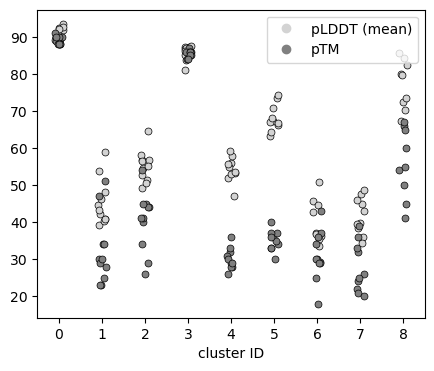

In [59]:
filter_ = filters['level_1_conserved_clusters']

fig, ax = plt.subplots(figsize=(5, 4))

sns.stripplot(figure_df[filter_], x='cluster_id', y='plddt_mean', color='lightgray', ax=ax, edgecolor='black', linewidth=0.5)
sns.stripplot(figure_df[filter_], x='cluster_id', y='scaled_ptm', color='gray', ax=ax, edgecolor='black', linewidth=0.5)

handles = [Line2D([], [], marker='o', linestyle='', color='lightgray', label='pLDDT (mean)')]
handles += [Line2D([], [], marker='o', linestyle='', color='gray', label='pTM')]
ax.legend(handles=handles)

ax.set_ylabel('')
ax.set_xlabel('cluster ID')
ax.set_xticks(ax.get_xticks(), labels=[str(int(i)) for i in ax.get_xticks()])
plt.show()



In [60]:
# def get_msa_num_seqs_bin(n):
#     if n < 5:
#         return '0-5'
#     elif n < 10:
#         return '5-10'
#     elif n < 20:
#         return '10-20'
#     else:
#         return '>20'

def get_msa_num_seqs_bin(n):
    if n == 0:
        return '0'
    elif n < 10:
        return '<10'
    else:
        return '>10'

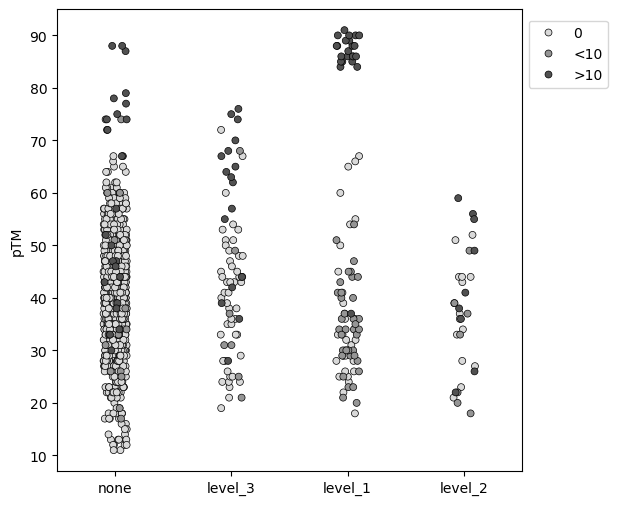

In [61]:
fig, ax = plt.subplots(figsize=(6, 6))

figure_df['has_msa'] = figure_df.msa_num_seqs > 0
figure_df['length'] = figure_df.seq.apply(len)

categories = dict()
for level, gene_ids in conserved_cluster_gene_ids.items():
    categories[f'level_{level}'] = figure_df.index.isin(gene_ids)
categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')
    
figure_df['msa_num_seqs_bin'] = figure_df.msa_num_seqs.apply(get_msa_num_seqs_bin)

palette = {True:'darkseagreen', False:'lightgray'}
sns.stripplot(figure_df.sort_values('msa_num_seqs'), x='category', y='scaled_ptm', hue='msa_num_seqs_bin', palette='Grays', legend=True, edgecolor='black', linewidth=0.5)

ax.legend(bbox_to_anchor=(1.2, 0.99))

ax.set_xlabel('')
ax.set_ylabel('pTM')
plt.show()

In [62]:
MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'

@dataclass
class Databases:
    input: str
    output_search: str
    output_align: str
    output_msa: str


def make_msas(path:str, databases=None, output_dir_path:str=MMSEQS_DIR, sensitivity=9.5):
    '''Use MMseqs align utilities to construct a3m-format alignment files for each sequence in the input FASTA file. The pipeline
    is as follows:
        (1) Use the input FASTA file to construct an MMseqs database. 
        (2) Generate a search result database by querying the input database against itself. 
        (3) Construct full alignments using the results of the search. 
        (4) Convert the alignments to MSAs. 
        (5) Unpack the alignment output info a3m files compatible with AlphaFold; there will be one file per query.
        
    :param path: The path to the FASTA file containing all sequences to create MSAs for. 
    :param databases: The Databases dataclass containing the paths and names for all requisite intermediate MMseqs databases.    
    :param output_dir_path: The directory where all final a3m files will be deposited. 
    :param sensitivity: The search sensitivity for the initial MMseqs search step. 
    '''
    subprocess.run(f'mmseqs createdb {path} {databases.input}', shell=True, check=True)
    subprocess.run(f'mmseqs search {databases.input} {databases.input} {databases.output_search} {MMSEQS_TMP_DIR} -s {sensitivity}', shell=True, check=True)
    subprocess.run(f'mmseqs align {databases.input} {databases.input} {databases.output_search} {databases.output_align}', shell=True, check=True)
    subprocess.run(f'mmseqs result2msa {databases.input} {databases.input} {databases.output_align} {databases.output_msa}', shell=True, check=True)
    subprocess.run(f'mmseqs unpackdb {databases.output_msa} {output_dir_path} --unpack-suffix .a3m', shell=True, check=True)

    # The unpacked database files just have numerical IDs, so want to rename according to their actual gene IDs. 
    # This is done by mapping the numerical ID to the original gene ID using the lookup table associated with the input database. 
    num_to_gene_id_map = pd.read_csv(databases.input + '.lookup', sep=r'\s+', names=['num', 'gene_id'], index_col=0, usecols=[0, 1]).gene_id.to_dict()
    for file_name in os.listdir(output_dir_path):
        if not re.match(r'\d+\.a3m', file_name):
            continue 
        n = int(re.match(r'(\d+)\.a3m', file_name).group(1))
        old_path = os.path.join(output_dir_path, file_name)
        new_path = os.path.join(output_dir_path, f'{num_to_gene_id_map[n]}.a3m')
        subprocess.run(f'mv {old_path} {new_path}', shell=True, check=True)

name = 'level_2_conserved_clusters'
databases = Databases(f'{MMSEQS_DATABASE_DIR}/{name}', f'{MMSEQS_DATABASE_DIR}/{name}.out', f'{MMSEQS_DATABASE_DIR}/{name}.aln', f'{MMSEQS_DATABASE_DIR}/{name}.msa')
# make_msas('../data/genes/level_2_conserved_clusters.faa', databases=databases)

# Clean up the created databases and folders.
for path in glob.glob(os.path.join(MMSEQS_DATABASE_DIR, '*')): 
    os.remove(path)
shutil.rmtree(MMSEQS_TMP_DIR, ignore_errors=True)


In [63]:
def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input'
ALPHAFOLD_INPUT_DIR = os.path.join(ALPHAFOLD_INPUT_DIR, 'level_1_conserved_clusters')
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

for row in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].itertuples():

    msas = dict()
    msas['unpaired'] = get_msas_unpaired([row.Index])
    input = AlphaFoldInputFile(row.Index, dialect='alphafold3', num_seeds=3, version=2)
    input.add_seq(row.seq, paired_msa='', unpaired_msa=msas['unpaired'][row.Index], n=1)
    input.write(os.path.join(ALPHAFOLD_INPUT_DIR, row.Index + '.json'))


output_dirs = [os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id) for gene_id in conserved_cluster_gene_ids[1]]
outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]
print(f'Loaded {len(outputs)} AlphaFold3 structures.')


Loaded 93 AlphaFold3 structures.


orfm.bz_4.1_107 (cluster_0): 0.88 to 0.51 (delta -0.37)	 ColabFold MSA has 1026 sequences.
orfm.bz_3.1_50 (cluster_1): 0.51 to 0.4 (delta -0.11)	 ColabFold MSA has 3 sequences.
orfm.bz_4.1_164 (cluster_1): 0.34 to 0.3 (delta -0.04)	 ColabFold MSA has 3 sequences.
orfm.bz_5.1_140 (cluster_1): 0.47 to 0.36 (delta -0.11)	 ColabFold MSA has 3 sequences.
orfm.bz_0.1_118 (cluster_4): 0.32 to 0.29 (delta -0.03)	 ColabFold MSA has 0 sequences.
orfm.bz_2.1_72 (cluster_5): 0.4 to 0.37 (delta -0.03)	 ColabFold MSA has 6 sequences.
orfm.bz_3.1_56 (cluster_6): 0.43 to 0.38 (delta -0.05)	 ColabFold MSA has 6 sequences.


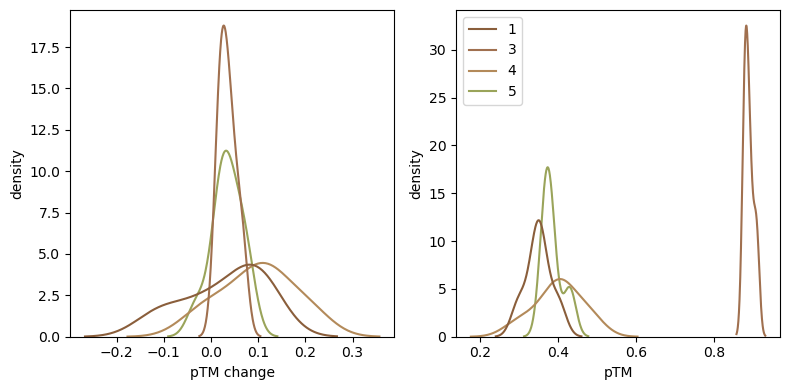

pTM for cluster 0: 0.51 - 0.93 mean pTM change -0.02
pTM for cluster 1: 0.3 - 0.4 mean pTM change 0.03
pTM for cluster 2: 0.63 - 0.79 mean pTM change 0.32
pTM for cluster 3: 0.88 - 0.91 mean pTM change 0.04
pTM for cluster 4: 0.29 - 0.49 mean pTM change 0.10
pTM for cluster 5: 0.36 - 0.43 mean pTM change 0.03
pTM for cluster 6: 0.28 - 0.55 mean pTM change 0.14
pTM for cluster 7: 0.53 - 0.63 mean pTM change 0.30
pTM for cluster 8: 0.73 - 0.81 mean pTM change 0.21


In [75]:
figure_df = list()
for output in outputs:
    gene_id = output.name
    row = {'gene_id':output.name}
    row['msa_colabfold'] = data[gene_id]['ptm']
    row['msa_colabfold_num_seqs'] = data[gene_id]['msa_num_seqs']
    row['msa_custom'] = max(output.get_ptms().values())
    row['cluster_id'] = str(int(genes_df.loc[gene_id].cluster_id))
    figure_df.append(row)

figure_df = pd.DataFrame(figure_df).sort_values('cluster_id')
figure_df['delta'] = figure_df.msa_custom - figure_df.msa_colabfold
for row in figure_df[figure_df.delta < 0].itertuples():
    print(f'{row.gene_id} (cluster_{row.cluster_id}): {row.msa_colabfold} to {row.msa_custom} (delta {row.delta:.2f})\t ColabFold MSA has {row.msa_colabfold_num_seqs} sequences.')

fig, axes = plt.subplots(ncols=2, figsize=(8, 4))

# cluster_id = '1'
# sns.kdeplot(figure_df[figure_df.cluster_id == cluster_id], x='delta', color='gray', common_norm=True, ax=axes[0])
# sns.kdeplot(figure_df[figure_df.cluster_id == cluster_id], x='msa_custom', color='gray', common_norm=True, ax=axes[1], label='custom MSA')
# sns.kdeplot(figure_df[figure_df.cluster_id == cluster_id], x='msa_colabfold', color='gray', common_norm=True, ax=axes[1], ls='--', label='ColabFold MSA')
# axes[1].legend()
cluster_ids = ['1', '4', '5', '3']
# cluster_ids = None

if cluster_ids is None:
    cluster_ids = figure_df.cluster_id.unique()
mask = figure_df.cluster_id.isin(cluster_ids)

sns.kdeplot(figure_df[mask], x='delta', hue='cluster_id', common_norm=False, ax=axes[0], legend=False)
sns.kdeplot(figure_df[mask], x='msa_custom', hue='cluster_id', common_norm=False, ax=axes[1], legend=True)
axes[1].get_legend().set_title('')

axes[0].set_ylabel('density')
axes[1].set_ylabel('density')
axes[0].set_xlabel('pTM change')
axes[1].set_xlabel('pTM')



# figure_df = figure_df.melt(id_vars=['gene_id', 'cluster_id'], value_name='ptm', value_vars=['msa_colabfold', 'msa_custom'], var_name='category')
# sns.stripplot(figure_df, x='category', y='ptm', hue='cluster_id', ax=ax)

fig.tight_layout()
plt.show()

for cluster_id, df in figure_df.groupby('cluster_id'):
    print(f'pTM for cluster {cluster_id}:', df.msa_custom.min(), '-', df.msa_custom.max(), f'mean pTM change {df.delta.mean():.2f}')

In [65]:
# In order to improve structure predictions further, attempted to recruit ggKbase homologs. 

ggkbase_df = BLASTFile.from_file('../data/genes/level_1_conserved_clusters-ggkbase.txt').to_df()
ggkbase_df['query_coverage'] = ggkbase_df.alignment_length / ggkbase_df.query_length
ggkbase_df['subject_coverage'] = ggkbase_df.alignment_length / ggkbase_df.subject_length
ggkbase_df['query_cluster_id'] = ggkbase_df.query_id.map(genes_df.cluster_id)

print('Number of unique hits across all clusters before filtering:', ggkbase_df.feature_id.nunique())

filters = dict()
filters['low_query_coverage'] = ggkbase_df.query_coverage < 0.75
filters['low_subject_coverage'] = ggkbase_df.subject_coverage < 0.75
filters['different_lengths'] = (np.abs(ggkbase_df.subject_length - ggkbase_df.query_length) / ggkbase_df.query_length) > 0.5
filters['low_percent_identity'] = ggkbase_df.percent_identity < 0.2 # Probably pushing what would make sense for an MSA. 

ggkbase_df = apply_filters(filters, ggkbase_df)

print('Number of unique hits across all clusters after filtering:', ggkbase_df.feature_id.nunique())

for cluster_id, df in ggkbase_df.groupby('query_cluster_id'):
    print(f'\nCluster {int(cluster_id)} ({df.feature_id.nunique()} unique hits)')
    print(f'Minimum percent identity: {100 * df.percent_identity.min():.2f}%')
    print(f'Minimum bit score: {df.bit_score.min()}')
    print(f'Maximum E-value: {df.e_value.max()}')

BLASTFile._from_ggkbase_text_file: Found 93 query entries in the file.
Number of unique hits across all clusters before filtering: 5994
apply_filters: 11144 entries removed by low_query_coverage.
apply_filters: 7524 entries removed by low_subject_coverage.
apply_filters: 2890 entries removed by different_lengths.
apply_filters: 5 entries removed by low_percent_identity.
Number of unique hits across all clusters after filtering: 2679

Cluster 0 (1834 unique hits)
Minimum percent identity: 20.43%
Minimum bit score: 87.4
Maximum E-value: 9e-14

Cluster 1 (119 unique hits)
Minimum percent identity: 23.58%
Minimum bit score: 39.3
Maximum E-value: 3.4

Cluster 2 (105 unique hits)
Minimum percent identity: 24.00%
Minimum bit score: 38.9
Maximum E-value: 7.3

Cluster 3 (159 unique hits)
Minimum percent identity: 20.73%
Minimum bit score: 40.4
Maximum E-value: 8.0

Cluster 4 (88 unique hits)
Minimum percent identity: 26.67%
Minimum bit score: 36.2
Maximum E-value: 6.3

Cluster 5 (106 unique hit

In [66]:
# cluster_ids = [2, 4, 6, 7, 8] # These are the clusters whose structures were markedly improved by the custom MSA. 

gene_ids = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].index.tolist()


output_dirs = [path for path in glob.glob('../data/genes/alphafold/af_output/*') if (get_gene_id(path) in gene_ids)]
outputs = [AlphaFoldOutput(path) for path in output_dirs]

def copy_structures(paths:list, dir_:str, rename=lambda path : get_gene_id(path) + '.cif'):
    '''Copy structures at the specified paths to the output (destination) directory. If a rename function is provided, the file paths 
    are renamed in the destination directory. 
    
    :param paths:
    :param dir_: The destination directory for the copied structure files.
    '''
    os.makedirs(dir_, exist_ok=True)
    for path in paths:
        new_file_name = os.path.basename(path) if (rename is None) else rename(path)
        new_path = os.path.join(dir_, new_file_name)
        subprocess.run(f'cp {path} {new_path}', shell=True, check=True)

# copy_structures([output.best_model_path for output in outputs], '../data/genes/foldseek/query/level_1_conserved_clusters/')

FOLDSEEK_FIELDS = 'query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob'
FOLDSEEK_DATABASE_NAMES = ['alphafold_swissprot', 'alphafold_uniprot', 'bfvd', 'pdb']
FOLDSEEK_DATABASE_PATHS = [f'/shared/db/foldseek/latest/db/{name}' for name in FOLDSEEK_DATABASE_NAMES]
FOLDSEEK_OUTPUT_PATHS = [f'/home/philippar/foldseek/level_1_conserved_clusters-{name}.tsv' for name in FOLDSEEK_DATABASE_NAMES]
FOLDSEEK_QUERY_PATH = '/home/philippar/foldseek/query/level_1_conserved_clusters/'

FOLDSEEK_PARAMS = dict()
FOLDSEEK_PARAMS['--alignment-type'] = '1'
FOLDSEEK_PARAMS['-a'] = ''
FOLDSEEK_PARAMS['--format-output'] = f'"{FOLDSEEK_FIELDS}"'

for database_path, output_path in zip(FOLDSEEK_DATABASE_PATHS, FOLDSEEK_OUTPUT_PATHS):
    cmd = [f'foldseek easy-search {FOLDSEEK_QUERY_PATH} {database_path} {output_path} tmp'] + [' '.join(params) for params in FOLDSEEK_PARAMS.items()] 
    cmd = ' '.join(cmd)
    print(cmd)



foldseek easy-search /home/philippar/foldseek/query/level_1_conserved_clusters/ /shared/db/foldseek/latest/db/alphafold_swissprot /home/philippar/foldseek/level_1_conserved_clusters-alphafold_swissprot.tsv tmp --alignment-type 1 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"
foldseek easy-search /home/philippar/foldseek/query/level_1_conserved_clusters/ /shared/db/foldseek/latest/db/alphafold_uniprot /home/philippar/foldseek/level_1_conserved_clusters-alphafold_uniprot.tsv tmp --alignment-type 1 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"
foldseek easy-search /home/philipp

In [67]:
list(conserved_cluster_gene_ids.keys())

[1, 2, 3]